In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
import zipfile
import os

zip_file_path = '/content/archive.zip'

extract_dir = '/content/extracted_dataset'

os.makedirs(extract_dir, exist_ok=True)

print(f"Extracting {zip_file_path} to {extract_dir}...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Extraction complete.")

print(f"Contents of {extract_dir}:")
for item in os.listdir(extract_dir):
    print(f"- {item}")

Extracting /content/archive.zip to /content/extracted_dataset...
Extraction complete.
Contents of /content/extracted_dataset:
- Symptom-severity.csv
- symptom_Description.csv
- dataset.csv
- symptom_precaution.csv


In [3]:
import pandas as pd
import os

extract_dir = '/content/extracted_dataset'

df = pd.read_csv(os.path.join(extract_dir, 'dataset.csv'))
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


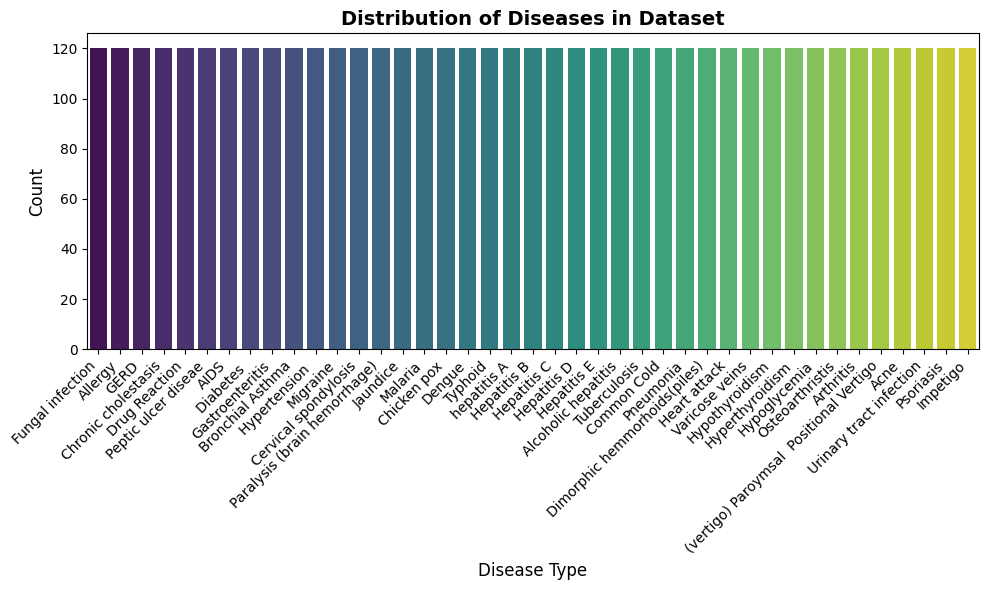

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='Disease', data=df, palette='viridis', hue='Disease', legend=False)

plt.title('Distribution of Diseases in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Disease Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [7]:
symptom_cols = [col for col in df.columns if 'Symptom' in col]
df[symptom_cols] = df[symptom_cols].fillna('No_Symptom')

df_encoded_symptoms = df.copy()
le_symptom = LabelEncoder()

all_unique_symptoms = pd.Series(dtype='object')
for col in symptom_cols:
    all_unique_symptoms = pd.concat([all_unique_symptoms, df_encoded_symptoms[col]])

le_symptom.fit(all_unique_symptoms.unique())

for col in symptom_cols:
    df_encoded_symptoms[col] = le_symptom.transform(df_encoded_symptoms[col])

print("DataFrame after encoding symptoms:")
df_encoded_symptoms.head()

DataFrame after encoding symptoms:


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,131,99,72,32,130,130,130,130,130,130,130,130,130,130,130,130,130
1,Fungal infection,99,72,32,130,130,130,130,130,130,130,130,130,130,130,130,130,130
2,Fungal infection,131,72,32,130,130,130,130,130,130,130,130,130,130,130,130,130,130
3,Fungal infection,131,99,32,130,130,130,130,130,130,130,130,130,130,130,130,130,130
4,Fungal infection,131,99,72,130,130,130,130,130,130,130,130,130,130,130,130,130,130


In [8]:
X = df_encoded_symptoms.drop('Disease', axis=1)
y = df_encoded_symptoms['Disease']

X_encoded = X.copy()
label_encoders = {}

for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = X_encoded[col].fillna('None').astype(str)
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

smote = SMOTE(k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y_encoded)

initial_feature_selector = SelectKBest(score_func=f_classif, k=10)
X_selected = initial_feature_selector.fit_transform(X_resampled, y_resampled)
initial_selected_10_feature_names = initial_feature_selector.get_feature_names_out(X_encoded.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_resampled, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")

Features scaled using StandardScaler.


In [10]:
num_features_to_select = len(symptom_cols) // 2

selector = SelectKBest(f_classif, k=num_features_to_select)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print(f"Selected top {num_features_to_select} features.")
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")

Selected top 8 features.
X_train_selected shape: (3936, 8)
X_test_selected shape: (984, 8)


In [11]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train_selected, y_train)

y_pred = rf_classifier.predict(X_test_selected)

print("Random Forest Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_))

Random Forest Classifier Evaluation:
Accuracy: 0.9522

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.49      1.00      0.65        18
                                   AIDS       1.00      1.00      1.00        30
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       0.93      1.00      0.96        25
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        23
                       Bronchial Asthma       1.00      1.00      1.00        33
                   Cervical spondylosis       1.00      1.00      1.00        23
                            Chicken pox       1.00      1.00      1.00        21
                    Chronic cholestasis       1.00      0.87      0.93        15
                            Co

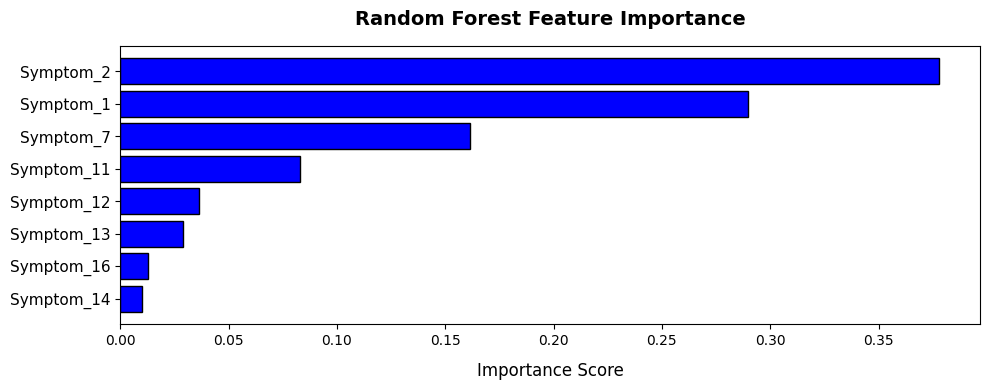

In [12]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf_classifier.feature_importances_
indices = np.argsort(importances)

feature_names = selector.get_feature_names_out(initial_selected_10_feature_names)
sorted_features = [feature_names[i] for i in indices]

plt.figure(figsize=(10, max(4, len(importances) * 0.45)))
plt.title("Random Forest Feature Importance", fontsize=14, fontweight='bold', pad=15)

plt.barh(range(len(importances)), importances[indices], align="center", color='blue', edgecolor='black')

plt.yticks(range(len(importances)), sorted_features, fontsize=11)
plt.xlabel('Importance Score', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

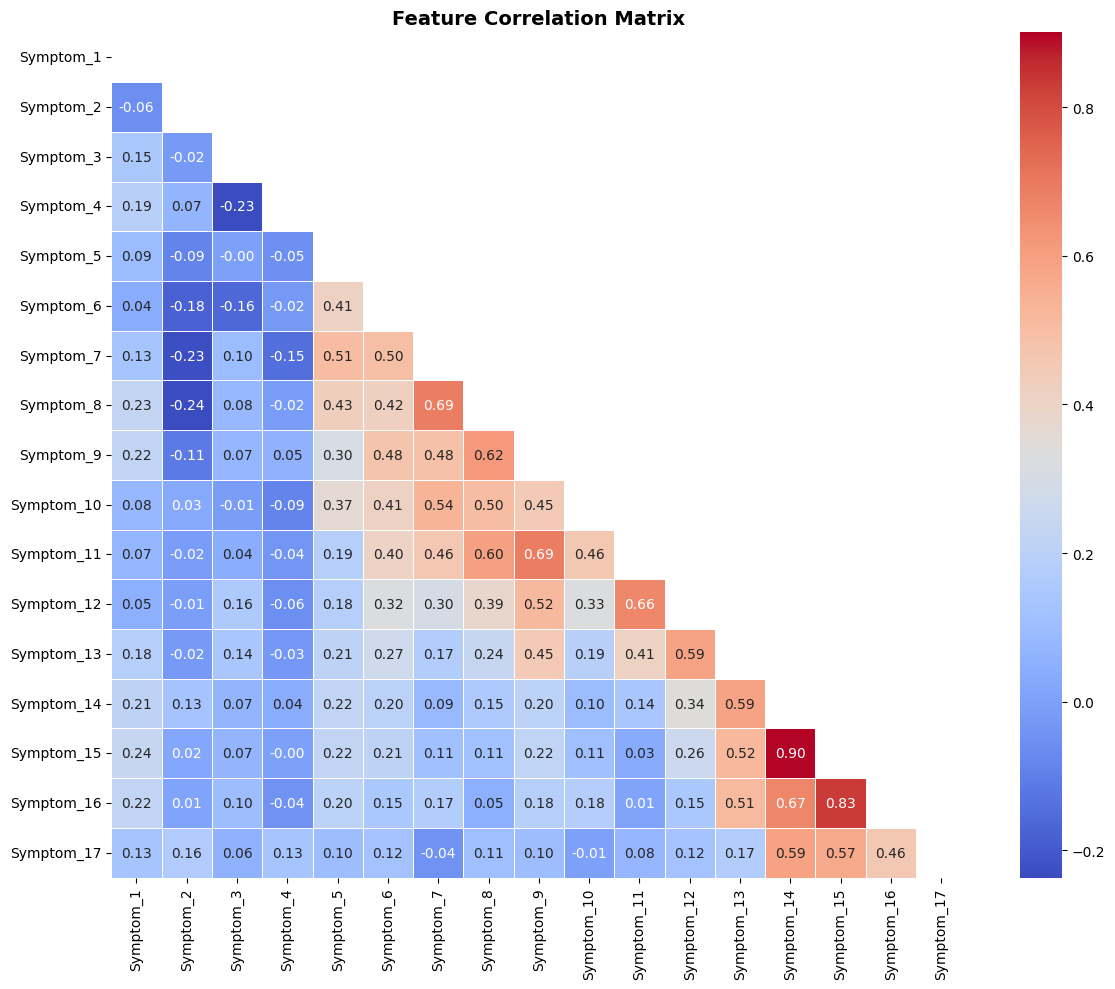

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 10))

corr_matrix = df_encoded_symptoms.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
joblib.dump(rf_classifier, 'random_forest_model.pkl')
joblib.dump(le_symptom, 'label_encoder_symptom.pkl')
joblib.dump(le_y, 'label_encoder_disease.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selector, 'feature_selector.pkl')
joblib.dump(initial_feature_selector, 'initial_feature_selector.pkl') # Save the initial selector
joblib.dump(initial_selected_10_feature_names, 'initial_selected_10_feature_names.pkl') # Save the 10 selected feature names

print("Model and preprocessing objects saved.")

Model and preprocessing objects saved.


In [15]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd

rf_classifier = joblib.load("random_forest_model.pkl")
le_symptom = joblib.load("label_encoder_symptom.pkl")
le_disease = joblib.load("label_encoder_disease.pkl")
scaler = joblib.load("scaler.pkl")
selector = joblib.load("feature_selector.pkl")
initial_feature_selector = joblib.load('initial_feature_selector.pkl')
initial_selected_10_feature_names = joblib.load('initial_selected_10_feature_names.pkl')

all_symptoms = list(le_symptom.classes_)

disease_recommendations = {
    '(vertigo) Paroymsal  Positional Vertigo': 'Consult a neurologist. Avoid sudden head movements.',
    'AIDS': 'Seek immediate medical attention for antiretroviral therapy and ongoing care.',
    'Acne': 'Maintain good skin hygiene, use topical treatments, and consult a dermatologist for severe cases.',
    'Alcoholic hepatitis': 'Strictly avoid alcohol. Consult a gastroenterologist for treatment options.',
    'Allergy': 'Identify and avoid allergens. Antihistamines or other allergy medications may be prescribed.',
    'Arthritis': 'Manage pain with medication, regular exercise, and physical therapy. Consult a rheumatologist.',
    'Bronchial Asthma': 'Carry an inhaler. Avoid triggers and follow a prescribed asthma action plan.',
    'Cervical spondylosis': 'Physical therapy, pain management, and posture correction are often recommended. Consult an orthopedist.',
    'Chicken pox': 'Rest, stay hydrated, and use lotions to relieve itching. Avoid contact with others to prevent spread.',
    'Chronic cholestasis': 'Medical management to relieve symptoms and address the underlying cause is essential. Consult a liver specialist.',
    'Common Cold': 'Rest, fluids, and over-the-counter medications to relieve symptoms. Wash hands frequently.',
    'Dengue': 'Rest, fluids, and fever-reducing medication. Avoid aspirin. Seek medical care if symptoms worsen.',
    'Diabetes ': 'Monitor blood sugar, follow a healthy diet, exercise regularly, and take prescribed medications. Consult an endocrinologist.',
    'Dimorphic hemmorhoids(piles)': 'Increase fiber intake, drink plenty of water, and use topical creams for relief.',
    'Drug Reaction': 'Discontinue the offending drug and seek medical attention immediately.',
    'Fungal infection': 'Apply antifungal creams or take oral medication as prescribed. Keep the affected area clean and dry.',
    'GERD': 'Lifestyle changes (diet, weight loss), antacids, or other medications to reduce stomach acid. Consult a gastroenterologist.',
    'Gastroenteritis': 'Rest, stay hydrated with clear fluids and electrolytes. Avoid solid food initially.',
    'Heart attack': 'Call emergency services immediately. Time is critical for treatment.',
    'Hepatitis B': 'Antiviral medications and regular monitoring are important. Consult a liver specialist.',
    'Hepatitis C': 'Antiviral medications are available for treatment. Consult a liver specialist.',
    'Hepatitis D': 'Managed with antiviral therapy, often in conjunction with Hepatitis B treatment. Consult a liver specialist.',
    'Hepatitis E': 'Usually resolves on its own. Rest and supportive care are important.',
    'Hypertension ': 'Monitor blood pressure, adopt a healthy lifestyle, and take prescribed medications. Regular check-ups are crucial.',
    'Hyperthyroidism': 'Medications, radioactive iodine therapy, or surgery may be options. Consult an endocrinologist.',
    'Hypoglycemia': 'Consume fast-acting carbohydrates (juice, candy). Identify and manage the underlying cause.',
    'Hypothyroidism': 'Treated with thyroid hormone replacement medication. Regular monitoring is essential.',
    'Impetigo': 'Antibiotic creams or oral antibiotics are used for treatment. Keep affected area clean.',
    'Jaundice': 'Identify and treat the underlying cause. May require medical intervention for liver issues.',
    'Malaria': 'Antimalarial drugs are used for treatment. Seek prompt medical attention.',
    'Migraine': 'Pain relievers, triptans, and preventative medications can be used. Identify and avoid triggers.',
    'Osteoarthristis': 'Pain management, physical therapy, exercise, and sometimes surgery. Consult an orthopedist.',
    'Paralysis (brain hemorrhage)': 'Requires emergency medical care. Rehabilitation and long-term support are necessary.',
    'Peptic ulcer diseae': 'Medications to reduce stomach acid, antibiotics for H. pylori. Avoid irritants. Consult a gastroenterologist.',
    'Pneumonia': 'Antibiotics (for bacterial), rest, and fluids. May require hospitalization in severe cases.',
    'Psoriasis': 'Topical treatments, light therapy, and systemic medications are used. Consult a dermatologist.',
    'Tuberculosis': 'Long course of antibiotics. Strict adherence to treatment is crucial.',
    'Typhoid': 'Antibiotics are the primary treatment. Maintain hygiene and sanitation.',
    'Urinary tract infection': 'Antibiotics are usually prescribed. Drink plenty of water.',
    'Varicose veins': 'Compression stockings, lifestyle changes, and medical procedures may be recommended.',
    'hepatitis A': 'Rest, fluids, and supportive care. Usually resolves on its own.'
}

def format_symptom_name(symptom_snake_case):
    if symptom_snake_case == 'No_Symptom':
        return symptom_snake_case
    return ' '.join([word.capitalize() for word in symptom_snake_case.split('_')])

selectable_symptoms_formatted = [format_symptom_name(s) for s in all_symptoms if s != "No_Symptom"]
selectable_symptoms_original_map = {format_symptom_name(s): s for s in all_symptoms if s != "No_Symptom"}

selectable_options = ['None'] + sorted(selectable_symptoms_formatted)

st.title("Disease Prediction")

st.markdown("This model can predict all the following diseases: ")
all_diseases_sorted = sorted(list(le_disease.classes_))
for disease in all_diseases_sorted:
    st.markdown(f"- {disease}")

st.write("Select symptoms to predict a disease.")

if 'num_symptom_slots' not in st.session_state:
    st.session_state.num_symptom_slots = 3

if 'symptom_values_formatted' not in st.session_state:
    st.session_state.symptom_values_formatted = ['None'] * 17

current_selected_symptoms_formatted = []
for i in range(st.session_state.num_symptom_slots):
    current_value = st.session_state.symptom_values_formatted[i]
    try:
        default_index = selectable_options.index(current_value)
    except ValueError:
        default_index = 0

    selected_option_formatted = st.selectbox(
        f'Symptom {i+1}:',
        selectable_options,
        index=default_index,
        key=f'symptom_select_{i}'
    )
    st.session_state.symptom_values_formatted[i] = selected_option_formatted

    if selected_option_formatted != 'None':
        current_selected_symptoms_formatted.append(selected_option_formatted)

if st.session_state.num_symptom_slots < 17:
    if st.button('Add another symptom'):
        st.session_state.num_symptom_slots += 1
        st.experimental_rerun()

if st.button('Predict Disease'):
    if not current_selected_symptoms_formatted:
        st.warning('Please select at least one symptom.')
    else:
        current_selected_symptoms_original = [
            selectable_symptoms_original_map[s]
            for s in current_selected_symptoms_formatted
        ]

        input_symptoms_padded = current_selected_symptoms_original + ['No_Symptom'] * (17 - len(current_selected_symptoms_original))
        input_symptoms_padded = input_symptoms_padded[:17] # Ensure it's exactly 17

        encoded_symptoms = le_symptom.transform(input_symptoms_padded)

        feature_cols_all_17 = [f'Symptom_{i+1}' for i in range(17)]
        input_df_all_17 = pd.DataFrame([encoded_symptoms], columns=feature_cols_all_17)

        input_df_filtered_10 = input_df_all_17[list(initial_selected_10_feature_names)]

        input_scaled = scaler.transform(input_df_filtered_10)

        input_selected = selector.transform(input_scaled)

        prediction_encoded = rf_classifier.predict(input_selected)
        predicted_disease = le_disease.inverse_transform(prediction_encoded)

        st.success(f'Based on the selected symptoms, the predicted disease is: - {predicted_disease[0]} -')

        recommendations = disease_recommendations.get(
            predicted_disease[0],
            'Consult a medical professional for accurate diagnosis and treatment.'
        )
        st.info(f'Recommendations: {recommendations}')

Overwriting app.py


In [16]:
!pip install streamlit -q
!npm install localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 51.3 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [17]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼your url is: https://gentle-snakes-notice.loca.lt


2026-08-11 17:27:57.331 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.201.250.130:8501

  Stopping...
^C
